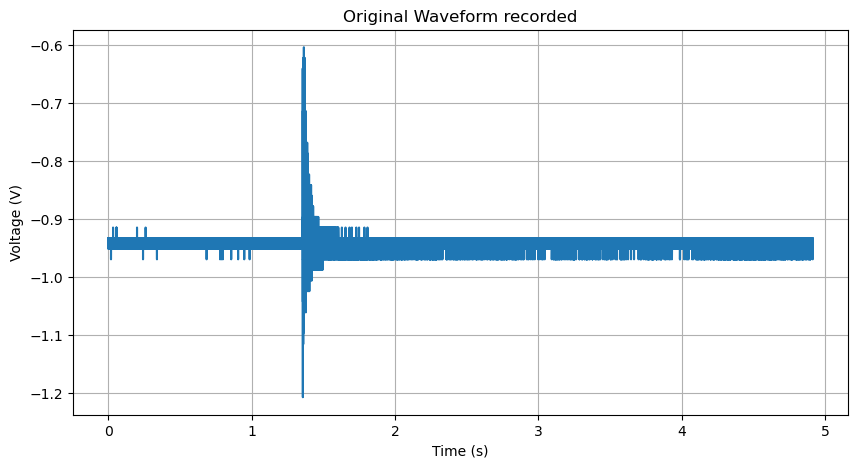

In [1]:
import pandas as pd
import numpy as np
from scipy.signal import find_peaks

# Load the CSV file
filepath = 'Drop1.csv'          # <-- set to your path

# Load the data, skipping the second row which contains units
df = pd.read_csv(filepath, sep=';', skiprows=[1])   # sep=';' : this file is semicolon-separated

import matplotlib.pyplot as plt
plt.figure(figsize=(10, 5))
plt.plot(df.iloc[:, 0], df.iloc[:, 1])
plt.title("Original Waveform recorded")
plt.xlabel("Time (s)")
plt.ylabel("Voltage (V)")
plt.grid(True)
plt.show()

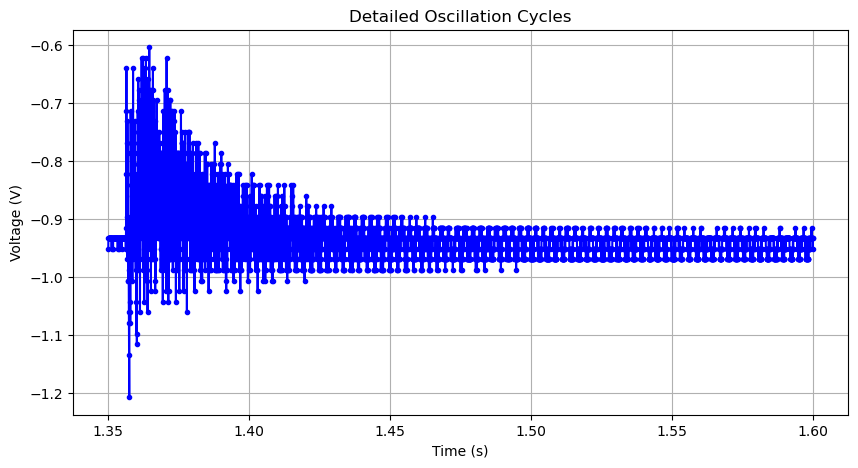

In [2]:
# Extract the actual trigger
df_cycles = df[(df['Time'] >= 1.35) & (df['Time'] <= 1.60)]

plt.figure(figsize=(10, 5))
plt.plot(df_cycles['Time'], df_cycles['Channel A'], 'b.-')
plt.title("Detailed Oscillation Cycles")
plt.xlabel("Time (s)")
plt.ylabel("Voltage (V)")
plt.grid(True)
plt.show()

Offset value: -0.9408947536375001
Number of samples: 4000
Peak frequency from FFT: 360.000000000839 Hz


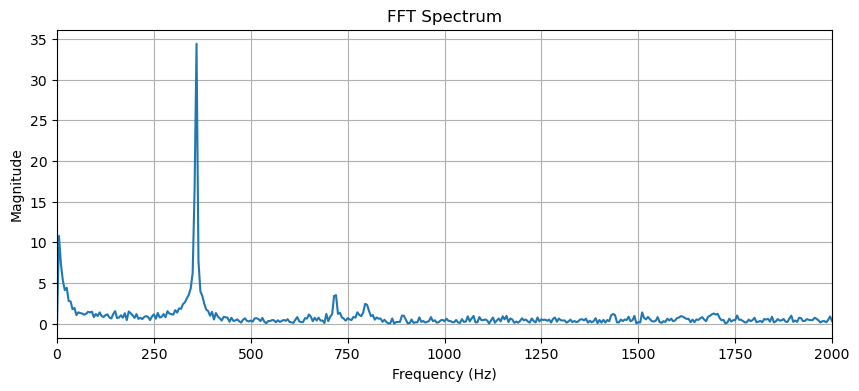

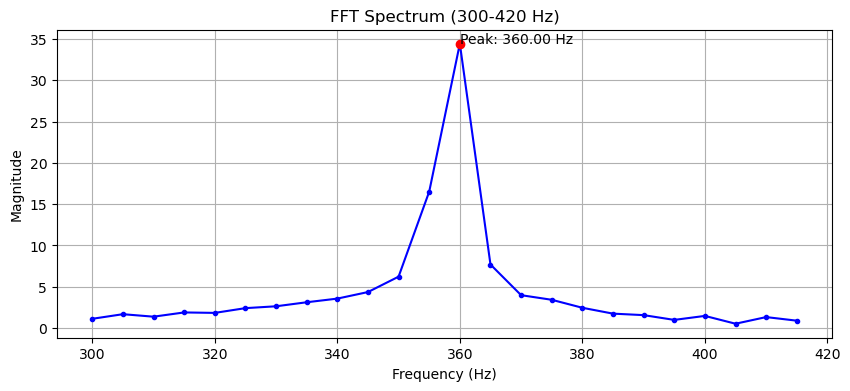

In [3]:
# Apply FFT to the extracted cycles to an interval of 'Pure unforced free vibration' (1.40 to 1.60 seconds)
df_fft = df[(df['Time'] >= 1.40) & (df['Time'] <= 1.60)]

# Sampling interval dt
dt = df_fft['Time'].iloc[1] - df_fft['Time'].iloc[0]
fs = 1.0 / dt

# Removing the offset value from the signal which centers the oscillation to zero
y = df_fft['Channel A'].values - np.mean(df_fft['Channel A'].values)
print(f"Offset value: {np.mean(df_fft['Channel A'].values)}")

# FFT
n = len(y)
print(f"Number of samples: {n}")
yf = np.fft.rfft(y)
xf = np.fft.rfftfreq(n, d=dt)

#include values from 300 to 420 Hz
xf_new = xf[(xf >= 300) & (xf <= 420)]
yf_new = yf[(xf >= 300) & (xf <= 420)]

# Peak frequency calculation
peak_idx = np.argmax(np.abs(yf))
peak_freq = xf[peak_idx]
print(f"Peak frequency from FFT: {peak_freq} Hz")

plt.figure(figsize=(10, 4))
plt.plot(xf, np.abs(yf))
plt.title("FFT Spectrum")
plt.xlabel("Frequency (Hz)")
plt.ylabel("Magnitude")
plt.xlim(0, 2000)
plt.grid(True)
plt.show()

# plot new graph with the new frequency range with data points marked
plt.figure(figsize=(10, 4))
plt.plot(xf_new, np.abs(yf_new), 'b.-')
plt.title("FFT Spectrum (300-420 Hz)")
plt.xlabel("Frequency (Hz)")
plt.ylabel("Magnitude")
plt.plot(peak_freq, np.abs(yf[peak_idx]), 'ro')
plt.annotate(f'Peak: {peak_freq:.2f} Hz', xy=(peak_freq, np.abs(yf[peak_idx])))
plt.grid(True)
plt.show()

Offset value: -0.9408947536375001


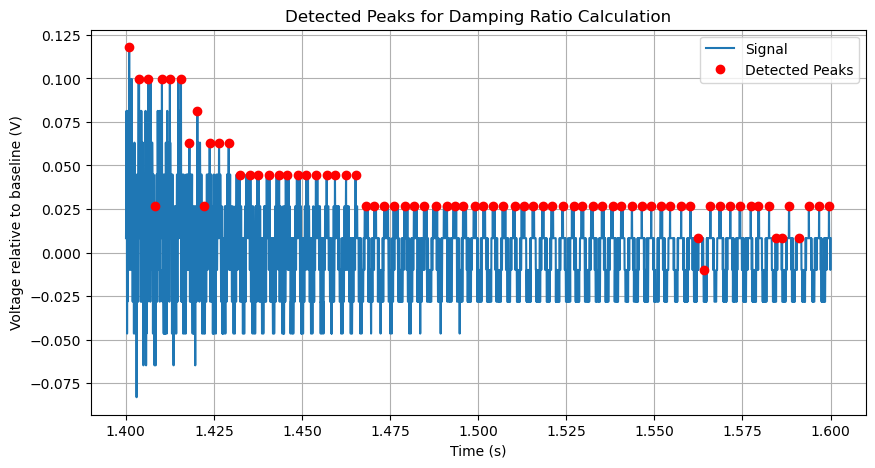

In [4]:
# Calculation of damping ratio using logarithmic decrement method
df_peaks = df[(df['Time'] >= 1.40) & (df['Time'] <= 1.60)].copy()
time = df_peaks['Time'].values
val = df_peaks['Channel A'].values

baseline = np.mean(val)
val_detrend = val - baseline
print(f"Offset value: {baseline}")

peaks, _ = find_peaks(val_detrend, distance=int(fs/600), prominence=0.005)

peak_times = time[peaks]
peak_vals = val_detrend[peaks]

plt.figure(figsize=(10, 5))
plt.plot(time, val_detrend, label='Signal')
plt.plot(peak_times, peak_vals, 'ro', label='Detected Peaks')
plt.title("Detected Peaks for Damping Ratio Calculation")
plt.xlabel("Time (s)")
plt.ylabel("Voltage relative to baseline (V)")
plt.legend()
plt.grid(True)
plt.show()

In [5]:
fd = peak_freq
wd = 2 * np.pi * fd

fit_mask = peak_vals > 0.002 # filter noise
fit_times = peak_times[fit_mask]
fit_log_vals = np.log(peak_vals[fit_mask])

slope, intercept = np.polyfit(fit_times - fit_times[0], fit_log_vals, 1)

decay_constant = -slope
zeta = decay_constant / np.sqrt(wd**2 + decay_constant**2)
fn = fd / np.sqrt(1 - zeta**2)

print(f"Decay constant (sigma): {decay_constant}")
print(f"Damping ratio (zeta): {zeta}")
print(f"Natural Frequency (fn): {fn} Hz")

Decay constant (sigma): 6.86584023426302
Damping ratio (zeta): 0.0030353538274235092
Natural Frequency (fn): 360.0016584194131 Hz


In [6]:
# ---------------- Quality Factor (self-contained) ----------------
# needs only: decay_constant (sigma, 1/s) and fd (damped frequency, Hz)
wd = 2 * np.pi * fd
zeta = decay_constant / np.sqrt(wd**2 + decay_constant**2)

Q = 1 / (2 * zeta)
print(f"Damping ratio (zeta): {zeta}")
print(f"Quality factor (Q): {Q}")

Damping ratio (zeta): 0.0030353538274235092
Quality factor (Q): 164.7254417203854


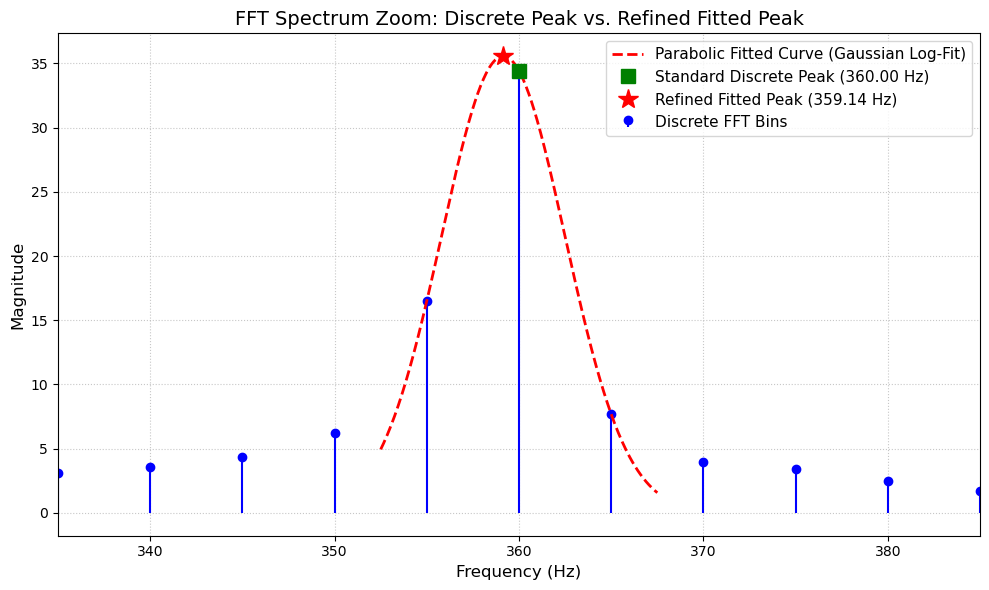

In [7]:
# --- Parabolic (Gaussian log-fit) peak refinement ---
df_bin = xf[1] - xf[0]
standard_peak_freq = xf[peak_idx]

# three FFT bins around the peak (log-magnitude) + peak magnitude for the marker
y_k   = np.abs(yf[peak_idx])
l_km1 = np.log(np.abs(yf[peak_idx - 1]))
l_k   = np.log(np.abs(yf[peak_idx]))
l_kp1 = np.log(np.abs(yf[peak_idx + 1]))

delta_fine = np.linspace(-1.5, 1.5, 300)
freq_fine = (peak_idx + delta_fine) * df_bin

a = 0.5 * (l_km1 - 2 * l_k + l_kp1)
b = 0.5 * (l_kp1 - l_km1)
c = l_k

# vertex of the parabola -> refined sub-bin peak
delta_peak = -b / (2 * a)
refined_peak_freq = (peak_idx + delta_peak) * df_bin
refined_mag = np.exp(c - (b**2) / (4 * a))

log_magnitude_fine = a * (delta_fine**2) + b * delta_fine + c
magnitude_fine = np.exp(log_magnitude_fine)

# Plot
plt.figure(figsize=(10, 6))
neighbor_indices = range(peak_idx - 8, peak_idx + 9)
plt.stem(xf[neighbor_indices], np.abs(yf[neighbor_indices]),
         linefmt='b-', markerfmt='bo', basefmt=" ", label='Discrete FFT Bins')
plt.plot(freq_fine, magnitude_fine, 'r--', linewidth=2, label='Parabolic Fitted Curve (Gaussian Log-Fit)')
plt.plot(standard_peak_freq, y_k, 'gs', markersize=10, label=f'Standard Discrete Peak ({standard_peak_freq:.2f} Hz)')
plt.plot(refined_peak_freq, refined_mag, 'r*', markersize=15, label=f'Refined Fitted Peak ({refined_peak_freq:.2f} Hz)')
plt.title("FFT Spectrum Zoom: Discrete Peak vs. Refined Fitted Peak", fontsize=14)
plt.xlabel("Frequency (Hz)", fontsize=12)
plt.ylabel("Magnitude", fontsize=12)
plt.xlim(standard_peak_freq - 25, standard_peak_freq + 25)
plt.grid(True, linestyle=':', alpha=0.7)
plt.legend(fontsize=11)
plt.tight_layout()
plt.show()